In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [2]:
from pathlib import Path

ml_folder = Path("06_ml")
list(ml_folder.iterdir())

FileNotFoundError: [WinError 3] The system cannot find the path specified: '06_ml'

In [3]:
from pathlib import Path
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
for item in Path(".").iterdir():
    print(item)

Current working directory:
c:\Users\homam\OneDrive\Desktop\intern-bootcamp\06_ml

Files/folders here:
baseline_model_results.csv
best_model.pkl
best_model_large.pkl
cross_validation_results.csv
feature_engineering.ipynb
large_baseline_model_results.csv
large_cross_validation_results.csv
large_data_experiment.ipynb
ml_intro.ipynb
ml_intro_summary.md
model_comparison.md
model_evaluation.ipynb
model_training.ipynb
README.md


In [4]:
model_path = Path("best_model_large.pkl")

best_model = joblib.load(model_path)

print("Model loaded successfully")
print(type(best_model))

Model loaded successfully
<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [5]:
project_root = Path("..")

print("Project root files/folders:")
for item in project_root.iterdir():
    print(item)

Project root files/folders:
..\.env
..\.env.example
..\.git
..\.gitignore
..\.venv
..\00_setup
..\01_sdlc
..\02_sql
..\03_mongo
..\04_data_eng
..\05_analytics
..\06_ml
..\07_genai_rag
..\08_chatbot
..\09_capstone
..\CONTRIBUTING.md
..\data
..\deleteme
..\docs
..\logs
..\practice_git.md
..\README.md
..\requirements.txt
..\second_practice.md


In [6]:
data_folder = Path("../data")

print("Data folder files/folders:")
for item in data_folder.iterdir():
    print(item)

Data folder files/folders:
..\data\processed
..\data\raw


In [7]:
raw_folder = Path("../data/raw")

print("Files inside data/raw:")
for item in raw_folder.iterdir():
    print(item)

Files inside data/raw:
..\data\raw\customers.csv
..\data\raw\orders.csv
..\data\raw\order_items.csv
..\data\raw\products.csv
..\data\raw\transactions.csv


In [8]:
processed_folder = Path("../data/processed")

print("Files inside data/processed:")
for item in processed_folder.iterdir():
    print(item)

Files inside data/processed:
..\data\processed\customers_clean.parquet
..\data\processed\features.csv
..\data\processed\features_large.csv
..\data\processed\logs
..\data\processed\orders_clean.parquet
..\data\processed\order_items_clean.parquet
..\data\processed\products_clean.parquet
..\data\processed\transactions_clean.parquet


In [9]:
model_path = Path("best_model_large.pkl")

best_model = joblib.load(model_path)

print("Model loaded successfully")
print(type(best_model))

Model loaded successfully
<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [10]:
features_path = Path("../data/processed/features_large.csv")

df = pd.read_csv(features_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (5000, 9)


,num__total_orders,num__total_spent,num__successful_payments,num__average_order_amount,will_reorder,cat__city_Abu Dhabi,cat__city_Ajman,cat__city_Dubai,cat__city_Sharjah
0,7,4739.61,5,677.09,1,False,False,False,True
1,20,1719.83,0,85.99,0,False,False,False,True
2,29,3638.66,9,125.47,1,False,True,False,False
3,15,2717.12,28,181.14,1,True,False,False,False
4,11,350.11,13,31.83,0,True,False,False,False


In [11]:
print("Columns in the dataset:")
for col in df.columns:
    print(col)

Columns in the dataset:
num__total_orders
num__total_spent
num__successful_payments
num__average_order_amount
will_reorder
cat__city_Abu Dhabi
cat__city_Ajman
cat__city_Dubai
cat__city_Sharjah


In [12]:
target_column = "will_reorder"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
for col in X.columns:
    print(col)

Features shape: (5000, 8)
Target shape: (5000,)

Feature columns:
num__total_orders
num__total_spent
num__successful_payments
num__average_order_amount
cat__city_Abu Dhabi
cat__city_Ajman
cat__city_Dubai
cat__city_Sharjah


In [13]:
print("Target value counts:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target value counts:
will_reorder
1    3407
0    1593
Name: count, dtype: int64

Target percentage:
will_reorder
1    68.14
0    31.86
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 8)
X_test shape: (1000, 8)
y_train shape: (4000,)
y_test shape: (1000,)


In [16]:
y_pred = best_model.predict(X_test)

print("Predictions created successfully")
print("First 10 predictions:")
print(y_pred[:10])

Predictions created successfully
First 10 predictions:
[1 1 1 0 1 1 0 1 1 0]


In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("------------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Model Evaluation Metrics
------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [18]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       319
           1       1.00      1.00      1.00       681

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



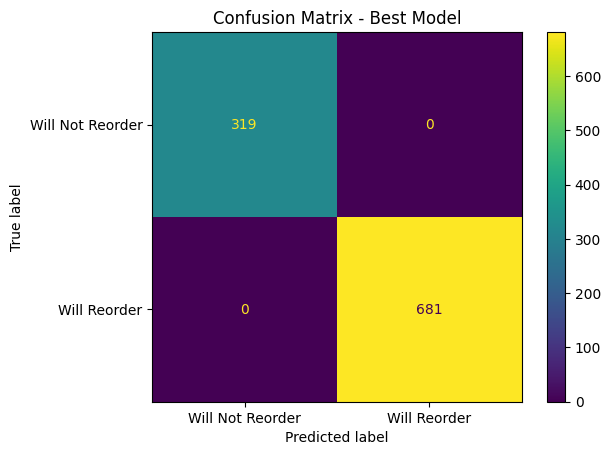

In [19]:
figures_folder = Path("../reports/figures")
figures_folder.mkdir(parents=True, exist_ok=True)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Will Not Reorder", "Will Reorder"]
)

disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.savefig(figures_folder / "confusion_matrix.png", bbox_inches="tight")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows that the model correctly predicted both classes on the test data.

The model correctly identified customers who will reorder and customers who will not reorder. There were no false positives and no false negatives in this test split.

This matches the evaluation metrics, where accuracy, precision, recall, and F1-score were all equal to 1.00.

However, because the result is perfect, it should be reviewed carefully. A perfect score may mean the model learned a very clear pattern, but it may also suggest that the target column is strongly derived from the same features used for prediction.

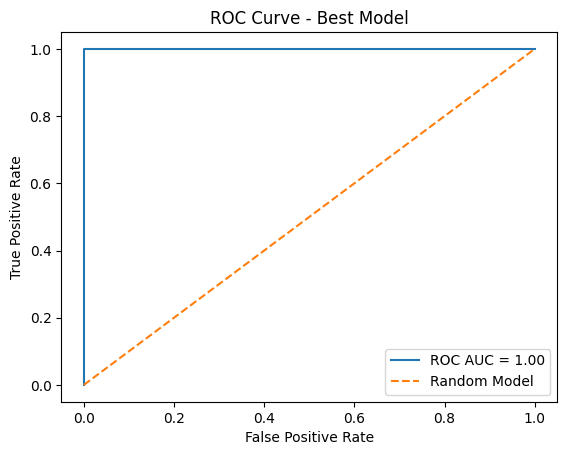

ROC AUC: 1.0


In [20]:
y_proba = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.savefig(figures_folder / "roc_curve.png", bbox_inches="tight")
plt.show()

print("ROC AUC:", round(roc_auc, 4))

## ROC Curve Interpretation

The ROC curve shows that the model separates the two classes perfectly on the test data.

The ROC AUC score is 1.00, which means the model can fully distinguish between customers who will reorder and customers who will not reorder.

The model performs much better than the random baseline line. However, because the ROC AUC is perfect, the dataset should be reviewed carefully to make sure there is no data leakage or overly simple target rule.

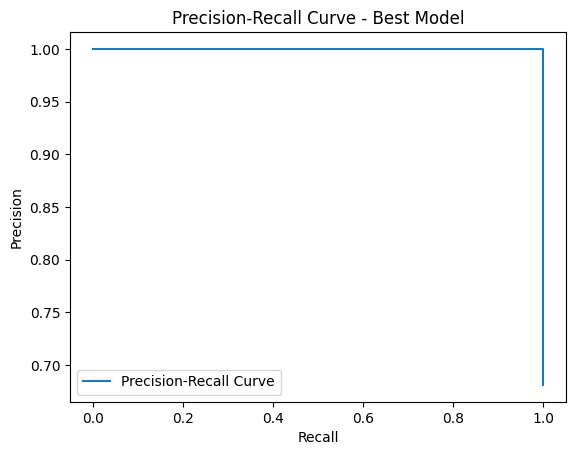

In [21]:
precision_values, recall_values, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recall_values, precision_values, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Best Model")
plt.legend()
plt.savefig(figures_folder / "precision_recall_curve.png", bbox_inches="tight")
plt.show()

## Precision-Recall Curve Interpretation

The Precision-Recall curve shows that the model performs very well when predicting the positive class, which is customers who will reorder.

The model has high precision and high recall. This means the model correctly identifies reorder customers and does not make many false positive predictions.

Since the performance is perfect, the result should still be checked carefully for possible data leakage or a very clear target rule.

In [22]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
0,num__total_orders,0.366540
2,num__successful_payments,0.362958
1,num__total_spent,0.270502
3,num__average_order_amount,0.000000
4,cat__city_Abu Dhabi,0.000000
5,cat__city_Ajman,0.000000
6,cat__city_Dubai,0.000000
7,cat__city_Sharjah,0.000000


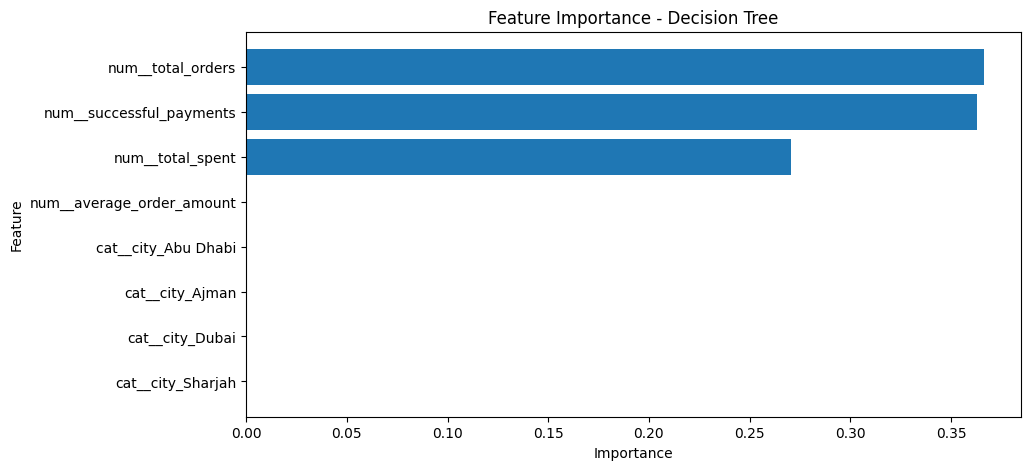

In [23]:
plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()

plt.savefig(figures_folder / "feature_importance.png", bbox_inches="tight")
plt.show()

## Feature Importance Interpretation

The feature importance chart shows that the Decision Tree model mainly used customer behavior features to make predictions.

The most important features were total orders, successful payments, and total spent. This means the model predicted whether a customer will reorder mostly based on past ordering and payment activity.

The city features had zero importance in this model. This suggests that customer location did not strongly affect the prediction in this dataset.

This result makes sense because customers with more orders, more successful payments, and higher spending are more likely to reorder.

In [24]:
print("Saved figures:")

for item in figures_folder.iterdir():
    print(item)

Saved figures:
..\reports\figures\confusion_matrix.png
..\reports\figures\feature_importance.png
..\reports\figures\precision_recall_curve.png
..\reports\figures\roc_curve.png


## Key Findings

The best model used in this evaluation was a Decision Tree Classifier trained on the larger dataset.

The model achieved perfect performance on the unseen test data. Accuracy, precision, recall, F1-score, and ROC AUC were all equal to 1.00.

The confusion matrix showed that the model correctly predicted all test examples, with no false positives and no false negatives.

The ROC curve and Precision-Recall curve also confirmed very strong model performance.

The feature importance chart showed that the most important features were total orders, successful payments, and total spent. This means the model mainly used customer behavior and payment activity to predict whether a customer will reorder.

The city features had zero importance, which means customer location did not affect the model predictions in this dataset.

Because the model achieved perfect results, the dataset should be reviewed carefully for possible data leakage or an overly simple target rule. In a real project, the model should also be tested on newer data from a different time period to confirm that it generalizes well.

# Day 4 — Model Evaluation and Interpretation

## Goal of this notebook

The goal of this notebook is to evaluate the best machine learning model on unseen test data.

In the previous task, I trained and compared different models. In this task, I will focus on testing the best model more deeply and understanding how it makes predictions.

In this notebook, I will:
- Load the trained model and test data.
- Evaluate the model using accuracy, precision, recall, F1-score, ROC AUC, and confusion matrix.
- Generate evaluation plots such as the confusion matrix, ROC curve, and precision-recall curve.
- Visualize feature importance.
- Interpret which features drive the predictions.
- Document the key findings and possible improvements.